# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, classification_report



In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Functions for automation

In [40]:
def distribution_plot(column):

    fig, axs = plt.subplots(1, 3, figsize = (18, 5))
    fig.suptitle(f'Distribution analysis')

    sns.histplot(column, ax = axs[0])
    axs[0].set_title('Histogram')

    stats.probplot(column, dist = "norm", plot = axs[1])
    axs[1].set_title('Probability Plot')

    sns.boxplot(x = column, ax = axs[2])
    axs[2].set_title('Boxplot')

    plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()


def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'!+', ' ! ', text)
    text = re.sub(r'\?+', ' ? ', text)
    text = re.sub(r'\*+', ' star ', text)
    text = re.sub(r'[^a-zA-Z!?\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[\(\)]', ' ', text)

    tokens = word_tokenize(text)

    processed_tokens = []

    for word in tokens:
        if word not in english_stopwords:
            if word.isalpha() and word != 'star':
                word = stemmer.stem(word)

            processed_tokens.append(word)

    return ' '.join(processed_tokens)

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def classify_analysis(targets, inputs, model, name='', label_encoder=None):

    pred = model.predict(inputs)

    if label_encoder is not None:
        pred_display = label_encoder.inverse_transform(pred)
        targets_display = label_encoder.inverse_transform(targets)
    else:
        pred_display = pred
        targets_display = targets

    f1 = f1_score(targets_display, pred_display, average='weighted')
    print(f'F1 score on {name}: {round(f1, 4)}\n')

    labels = np.unique(np.concatenate([targets_display, pred_display]))

    cf = confusion_matrix(
        targets_display,
        pred_display,
        normalize='true',
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cf,
        annot=True,
        xticklabels=labels,
        yticklabels=labels,
        cmap='Blues',
        fmt='.2f'
    )

    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

    print(f"\nClassification Report for {name}:\n")
    print(classification_report(targets_display, pred_display))

    if hasattr(model, "predict_proba"):
        try:

            y_proba = model.predict_proba(inputs)

            roc_auc = roc_auc_score(
                targets,
                y_proba,
                multi_class='ovr',
                average='weighted'
            )

            print(f'\nAUROC for {name}: {round(roc_auc, 4)}')

        except Exception as e:
            print("\nROC-AUC could not be calculated:", str(e))

def importance_features(model, vectorizer, n=10):

    feature_names = vectorizer.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance_df.head(n))

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=importance_df.head(n),
        x='importance',
        y='feature'
    )
    plt.title("Top Feature Importances")
    plt.show()


# Data loading

In [5]:
raw_df = pd.read_csv('tweet_sentiment_train.csv.zip')
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [7]:
print("Кількість пропущених значень:", raw_df.isnull().values.sum())

Кількість пропущених значень: 2


In [8]:
raw_df = raw_df.dropna(subset = ['text', 'selected_text'])
print("Кількість пропущених значень:", raw_df.isnull().values.sum())
raw_df.head()

Кількість пропущених значень: 0


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


# Exploratory Data Analysis

In [9]:
raw_df['sentiment'].value_counts(normalize = True)

sentiment
neutral     0.404549
positive    0.312300
negative    0.283151
Name: proportion, dtype: float64

count    27480.00
mean        68.33
std         35.60
min          3.00
25%         39.00
50%         64.00
75%         97.00
max        141.00
Name: text, dtype: float64

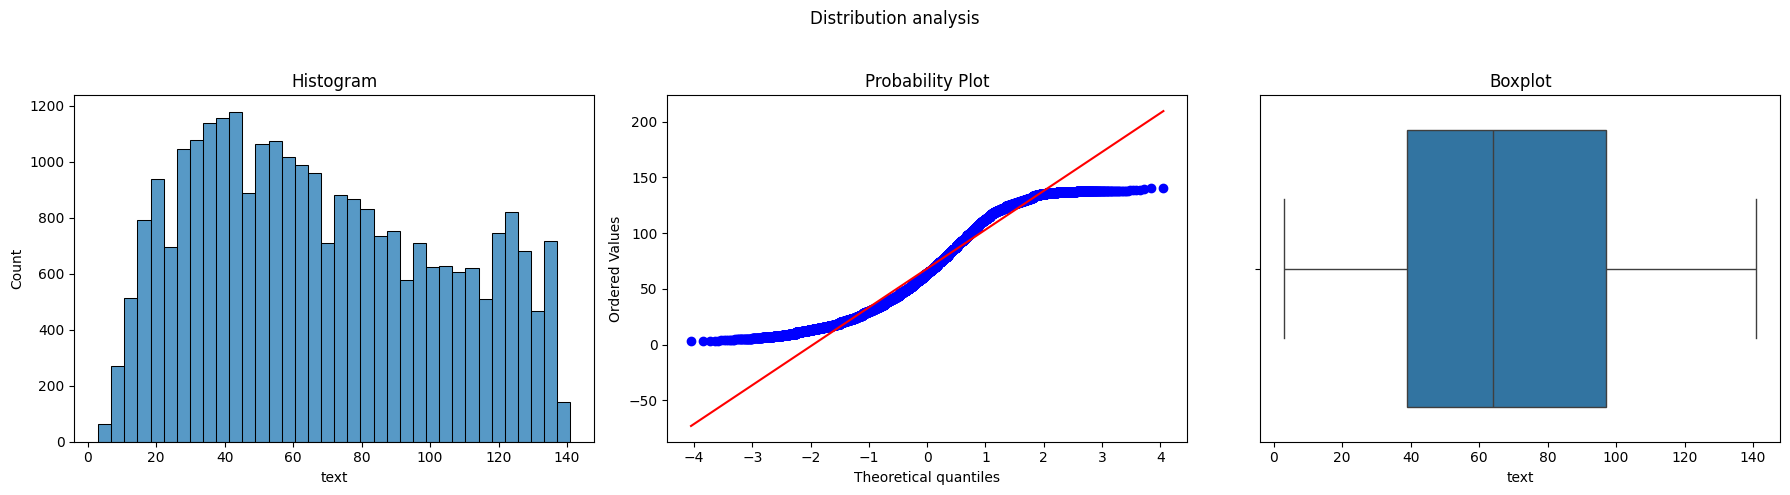

In [10]:
text_len = raw_df['text'].str.len()
display(text_len.describe().round(2))
distribution_plot(text_len)

In [11]:
raw_df[raw_df['sentiment'] == 'neutral'][:10]

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
7,50e14c0bb8,Soooo high,Soooo high,neutral
8,e050245fbd,Both of you,Both of you,neutral
10,2339a9b08b,"as much as i love to be hopeful, i reckon the...","as much as i love to be hopeful, i reckon the ...",neutral
14,bbe3cbf620,test test from the LG enV2,test test from the LG enV2,neutral
19,40e7becabf,Hes just not that into you,Hes just not that into you,neutral
20,04d17ef61e,"oh Marly, I`m so sorry!! I hope you find her...","oh Marly, I`m so sorry!! I hope you find her ...",neutral
22,7de057cf40,is cleaning the house for her family who is co...,is cleaning the house for her family who is co...,neutral
23,9ce5570064,gotta restart my computer .. I thought Win7 wa...,gotta restart my computer .. I thought Win7 wa...,neutral


count    11117.00
mean        65.21
std         36.41
min          3.00
25%         35.00
50%         59.00
75%         94.00
max        141.00
Name: text, dtype: float64

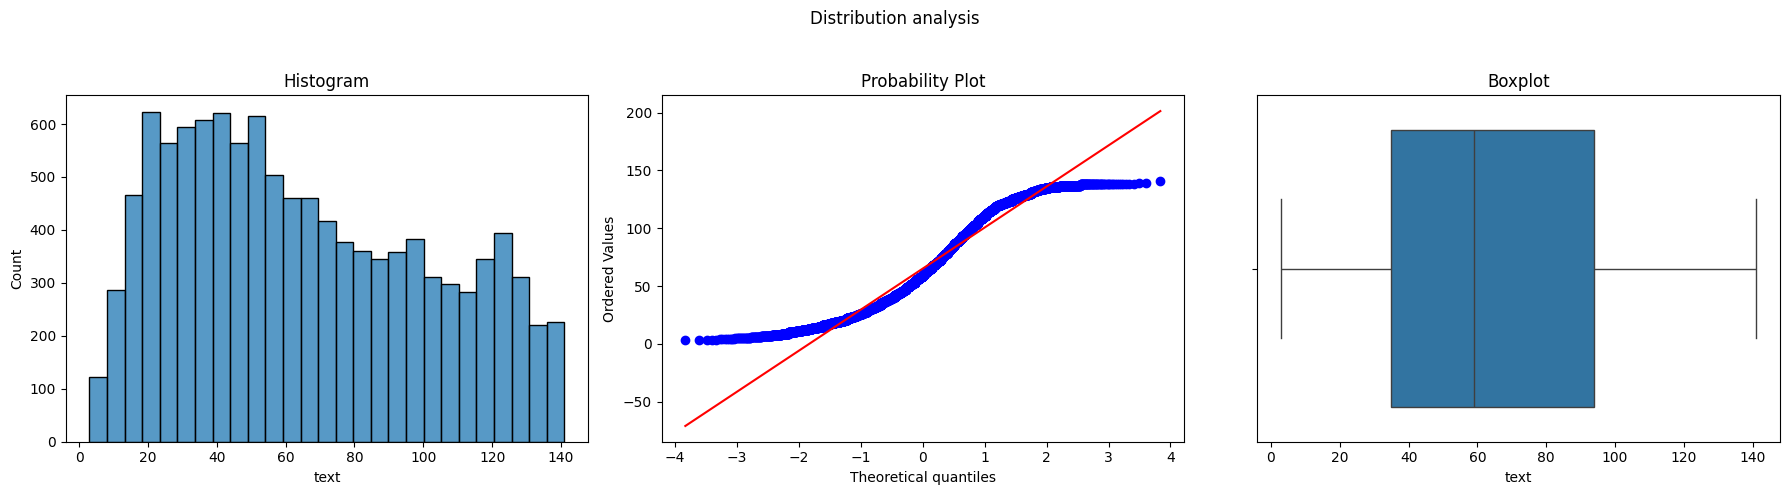

In [12]:
text_netural_len = raw_df[raw_df['sentiment'] == 'neutral']['text'].str.len()
display(text_netural_len.describe().round(2))
distribution_plot(text_netural_len)

In [13]:
raw_df[raw_df['sentiment'] == 'positive'][:10]

,textID,text,selected_text,sentiment
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive
11,16fab9f95b,I really really like the song Love Story by Ta...,like,positive
21,e48b0b8a23,Playing Ghost Online is really interesting. Th...,interesting.,positive
25,e00c6ef376,"the free fillin` app on my ipod is fun, im add...","the free fillin` app on my ipod is fun, im add...",positive
28,6ce4a4954b,juss came backk from Berkeleyy ; omg its madd ...,fun,positive
30,d33f811375,I`m going home now. Have you seen my new twitt...,Quite....heavenly,positive
31,7d8c4c11e4,i hope unni will make the audition . fighting ...,hope,positive
33,2dc51711bc,That`s very funny. Cute kids.,funny.,positive
39,2863f435bd,A little happy for the wine jeje ok it`sm my f...,A little happy fo,positive


count    8582.00
mean       70.42
std        34.65
min         5.00
25%        42.00
50%        67.00
75%        98.00
max       138.00
Name: text, dtype: float64

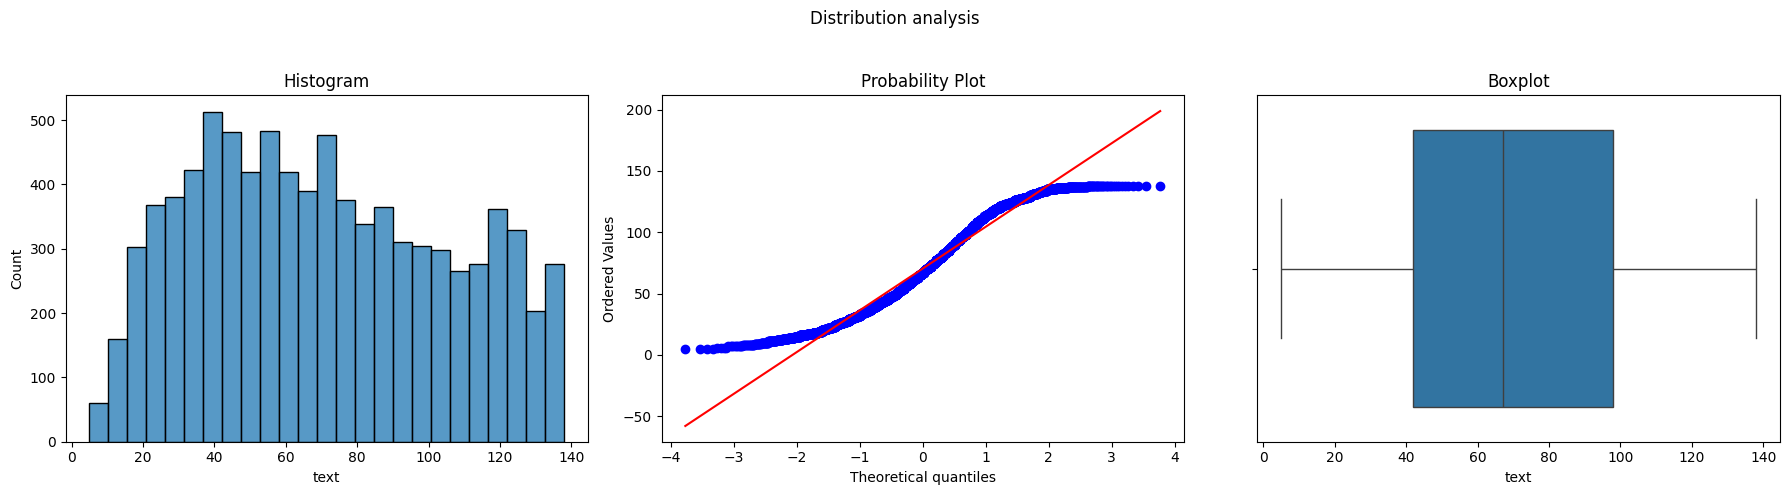

In [14]:
text_positive_len = raw_df[raw_df['sentiment'] == 'positive']['text'].str.len()
display(text_positive_len.describe().round(2))
distribution_plot(text_positive_len)

In [15]:
raw_df[raw_df['sentiment'] == 'negative'][:10]

,textID,text,selected_text,sentiment
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
12,74a76f6e0a,My Sharpie is running DANGERously low on ink,DANGERously,negative
13,04dd1d2e34,i want to go to music tonight but i lost my vo...,lost,negative
15,8a939bfb59,"Uh oh, I am sunburned","Uh oh, I am sunburned",negative
16,3440297f8b,"S`ok, trying to plot alternatives as we speak...",*sigh*,negative
17,919fa93391,i`ve been sick for the past few days and thus...,sick,negative
18,af3fed7fc3,is back home now gonna miss every one,onna,negative


count    7781.00
mean       70.49
std        35.16
min         5.00
25%        42.00
50%        66.00
75%        98.00
max       141.00
Name: text, dtype: float64

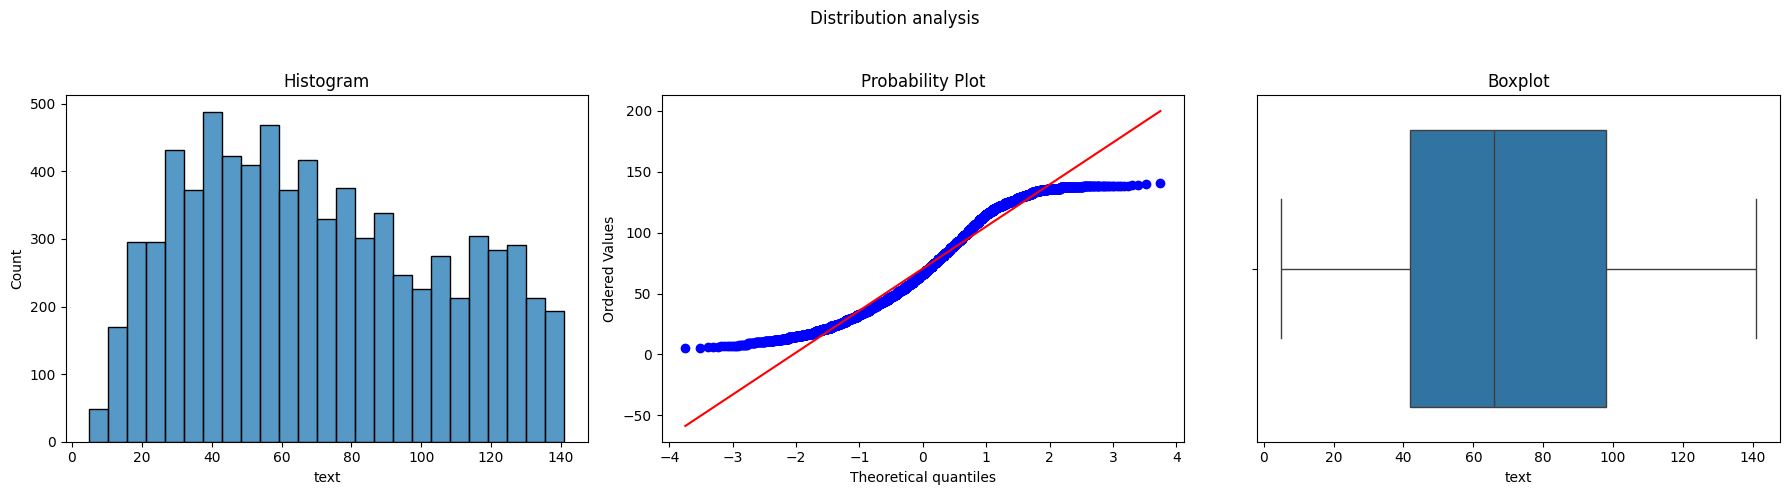

In [16]:
text_negative_len = raw_df[raw_df['sentiment'] == 'negative']['text'].str.len()
display(text_negative_len.describe().round(2))
distribution_plot(text_negative_len)

**Observation**
- Positive and negative classes are represented almost evenly, neutral class slightly exceeds other classes, but overall class distribution is quite close to balanced.
- Half of the available texts in the dataset are up to 64 characters long. Neutral and negative sentiment texts have the largest number of characters (141), the longest positive post is 138. At the same time, about half of positive and negative posts exceed neutral posts (67 and 66, respectively) in length (59).

# Preprocessing of text data and vectorization with bag of words

In [17]:
english_stopwords = stopwords.words('english')
english_stopwords.remove('not')
english_stopwords.remove('no')
english_stopwords.remove('nor')

stemmer = SnowballStemmer(language = 'english')

raw_df['clean_text'] = raw_df['text'].apply(preprocess_text)
raw_df[['text', 'clean_text']]

,text,clean_text
0,"I`d have responded, if I were going",respond go
1,Sooo SAD I will miss you here in San Diego!!!,soo sad miss san diego !
2,my boss is bullying me...,boss bulli
3,what interview! leave me alone,interview ! leav alon
4,"Sons of ****, why couldn`t they put them on t...",son star put releas alreadi bought
...,...,...
27476,wish we could come see u on Denver husband l...,wish could come see u denver husband lost job ...
27477,I`ve wondered about rake to. The client has ...,wonder rake client made clear net forc dev lea...
27478,Yay good for both of you. Enjoy the break - y...,yay good enjoy break probabl need hectic weeke...
27479,But it was worth it ****.,worth star


Pre-processing of text data in this case was carried out as follows:
- all posts were converted to lowercase
- duplicate characters and occurrences of words (sooo / soo - soo) were removed
- emoticon fragment *** was replaced with star
- stop words were removed except for not, no, nor, which in this case could probably be factors for determining negative sentiment
- stemming was applied

In [18]:
all_words = ' '.join(raw_df['clean_text']).split()
unique_words = list(all_words)
print('Кількість унікальних слів:', len(unique_words))

word_freq = Counter(all_words)
print('Найчастіші слова')
print(word_freq.most_common(30))

Кількість унікальних слів: 211331
Найчастіші слова
[('!', 10830), ('?', 3439), ('day', 2497), ('go', 2384), ('not', 1919), ('get', 1917), ('star', 1883), ('good', 1624), ('work', 1530), ('love', 1501), ('like', 1462), ('no', 1393), ('got', 1262), ('today', 1155), ('time', 1106), ('one', 1077), ('lol', 1029), ('happi', 1016), ('want', 991), ('thank', 990), ('know', 981), ('u', 971), ('miss', 969), ('back', 920), ('realli', 919), ('see', 907), ('think', 884), ('feel', 875), ('im', 859), ('night', 819)]


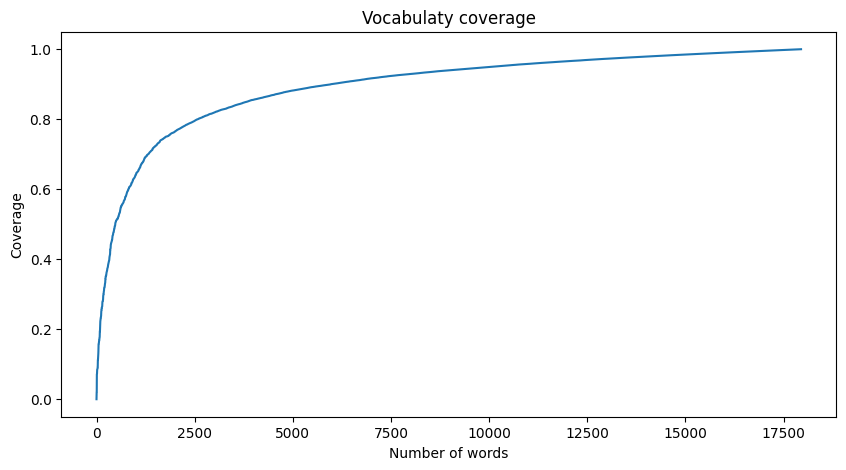

In [19]:
freq_df = pd.DataFrame(
    word_freq.items(),
    columns = ['word', 'freq']
)

freq_df['cumulative_freq'] = freq_df['freq'].cumsum()
total = freq_df['freq'].sum()
freq_df['coverage'] = (freq_df['cumulative_freq'] / total)

plt.figure(figsize = (10, 5))
plt.plot(freq_df['coverage'].values)
plt.xlabel('Number of words')
plt.ylabel('Coverage')
plt.title('Vocabulaty coverage')
plt.show()

**Observation**
- Word frequency analysis indicates that most tokens are concentrated in a small number of the most commonly used words, as a result of which max_feature was chosen at the level of 5000. Since this number of words covers about 85-90% of the corpus while minimizing possible unnecessary noise.
- Also, when forming the Bag of words, consideration of bigrams was added, which should probably take into account such cases as not bad, very good, etc.

In [20]:
vectorizer = CountVectorizer(
    max_features = 5000,
    min_df = 3,
    max_df = 0.8,
    ngram_range = (1, 2)
)

bow = vectorizer.fit_transform(raw_df['clean_text'])
print('Розмірніст словника', bow.shape)
print(vectorizer.get_feature_names_out()[:50])

Розмірніст словника (27480, 5000)
['aah' 'aahh' 'abandon' 'abil' 'abl' 'abl get' 'absolut' 'abt' 'ac'
 'academi' 'accept' 'access' 'accid' 'accident' 'accomplish' 'accord'
 'account' 'ace' 'ach' 'achiev' 'ack' 'across' 'act' 'action' 'activ'
 'actress' 'actual' 'ad' 'adam' 'add' 'addict' 'address' 'admit' 'adopt'
 'ador' 'adult' 'advanc' 'advantag' 'adventur' 'advert' 'advic' 'affect'
 'afford' 'afraid' 'afternoon' 'afterward' 'age' 'ago' 'agre' 'ah']


# Building a classifier

In [21]:
raw_df = raw_df.reset_index(drop=True)
train_idx, test_idx = train_test_split(raw_df.index, test_size = 0.3, random_state = 42, stratify = raw_df.sentiment)

X_train_bow = bow[train_idx]
X_test_bow = bow[test_idx]
y_train = raw_df.loc[train_idx, 'sentiment']
y_test = raw_df.loc[test_idx, 'sentiment']

print('Розмірність навчальної матриці ознак:', X_train_bow.shape)
print('Розмірність тестової матриці ознак:', X_test_bow.shape)
print('Розмірність навчального цільового показника:', y_train.shape)
print('Розмірність тестового цільового показника:', y_test.shape)

Розмірність навчальної матриці ознак: (19236, 5000)
Розмірність тестової матриці ознак: (8244, 5000)
Розмірність навчального цільового показника: (19236,)
Розмірність тестового цільового показника: (8244,)


## Logistic regression

In [22]:
MAX_ITER = 1000

log_model = LogisticRegression(max_iter = MAX_ITER, solver='sag')
log_model.fit(X_train_bow, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

F1 score on Training: 0.8412



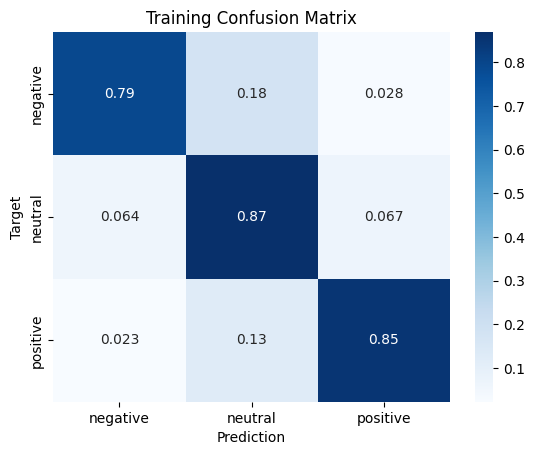


Classification Report for Training:

              precision    recall  f1-score   support

    negative       0.87      0.79      0.83      5447
     neutral       0.79      0.87      0.83      7782
    positive       0.88      0.85      0.87      6007

    accuracy                           0.84     19236
   macro avg       0.85      0.84      0.84     19236
weighted avg       0.84      0.84      0.84     19236


AUROC for Training: 0.9482
F1 score on Validation: 0.6891



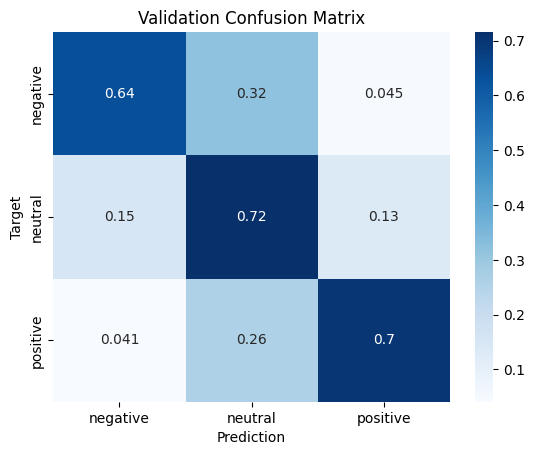


Classification Report for Validation:

              precision    recall  f1-score   support

    negative       0.71      0.64      0.67      2334
     neutral       0.63      0.72      0.67      3335
    positive       0.77      0.70      0.73      2575

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.69      8244
weighted avg       0.69      0.69      0.69      8244


AUROC for Validation: 0.8318


In [23]:
classify_analysis(y_train, X_train_bow, log_model, 'Training')
classify_analysis(y_test, X_test_bow, log_model, 'Validation')

## Decision Tree Classifier

In [24]:
random_param_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state = 42),
    random_param_dt,
    n_iter = 50,
    scoring = 'f1_weighted',
    cv = 5,
    n_jobs = -1,
    random_state = 42
)

In [25]:
dt = dt_random.fit(X_train_bow, y_train)
dt_model = dt.best_estimator_

In [26]:
print("Найкращі параметри:", dt.best_params_)
print("Найкращий CV F1:", round(dt.best_score_, 4))

Найкращі параметри: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': None, 'criterion': 'entropy'}
Найкращий CV F1: 0.6909


F1 score on Training: 0.7519



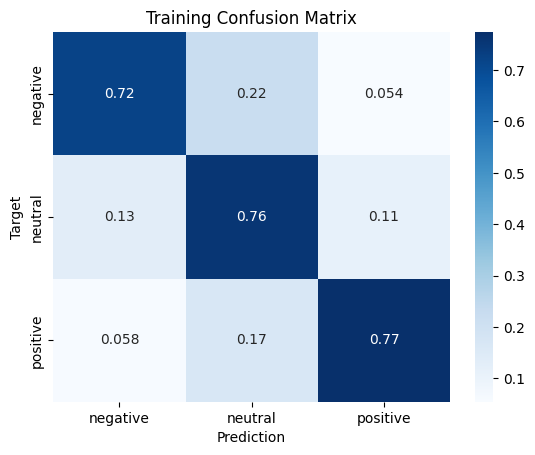


Classification Report for Training:

              precision    recall  f1-score   support

    negative       0.74      0.72      0.73      5447
     neutral       0.73      0.76      0.74      7782
    positive       0.80      0.77      0.79      6007

    accuracy                           0.75     19236
   macro avg       0.75      0.75      0.75     19236
weighted avg       0.75      0.75      0.75     19236


AUROC for Training: 0.9033
F1 score on Validation: 0.6919



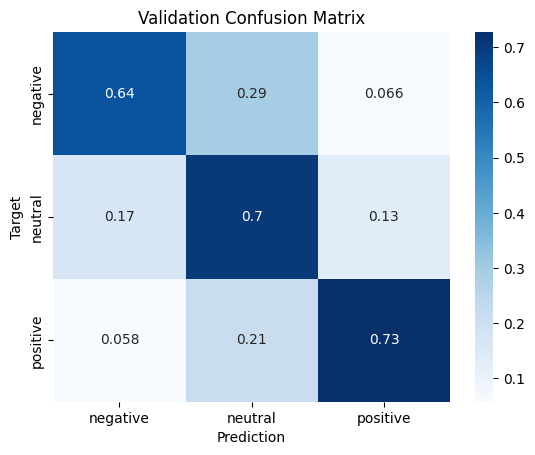


Classification Report for Validation:

              precision    recall  f1-score   support

    negative       0.68      0.64      0.66      2334
     neutral       0.65      0.70      0.68      3335
    positive       0.76      0.73      0.74      2575

    accuracy                           0.69      8244
   macro avg       0.70      0.69      0.69      8244
weighted avg       0.69      0.69      0.69      8244


AUROC for Validation: 0.8215


In [27]:
classify_analysis(y_train, X_train_bow, dt_model, 'Training')
classify_analysis(y_test, X_test_bow, dt_model, 'Validation')

## XGBoost

In [28]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

In [43]:
random_param_xgb = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
}


xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state = 42, objective = 'multi:softprob', num_class = 3),
    random_param_xgb,
    n_iter = 20,
    scoring = 'f1_weighted',
    cv = 5,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

In [44]:
xgb_random = xgb_random.fit(X_train_bow, y_train_enc)
xgb_model = xgb_random.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [45]:
print("Найкращі параметри:", xgb_random.best_params_)
print("Найкращий CV F1:", round(xgb_random.best_score_, 4))

Найкращі параметри: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Найкращий CV F1: 0.7187


F1 score on Training: 0.8002



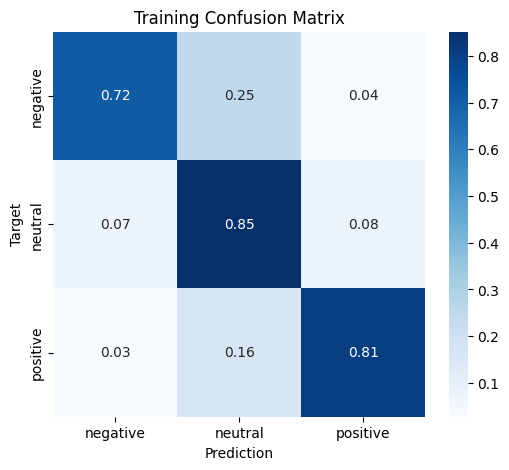


Classification Report for Training:

              precision    recall  f1-score   support

    negative       0.84      0.72      0.77      5447
     neutral       0.74      0.85      0.79      7782
    positive       0.86      0.81      0.83      6007

    accuracy                           0.80     19236
   macro avg       0.81      0.79      0.80     19236
weighted avg       0.81      0.80      0.80     19236


AUROC for Training: 0.9245
F1 score on Validation: 0.7132



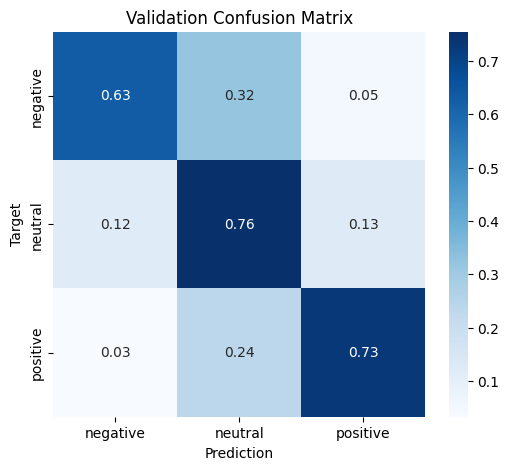


Classification Report for Validation:

              precision    recall  f1-score   support

    negative       0.75      0.63      0.69      2334
     neutral       0.65      0.76      0.70      3335
    positive       0.78      0.73      0.75      2575

    accuracy                           0.71      8244
   macro avg       0.73      0.71      0.71      8244
weighted avg       0.72      0.71      0.71      8244


AUROC for Validation: 0.8514


In [46]:
classify_analysis(y_train_enc, X_train_bow, xgb_model, 'Training', label_encoder=label_encoder)
classify_analysis(y_test_enc, X_test_bow, xgb_model, 'Validation', label_encoder=label_encoder)

**Observation**
- The best results on the training sample were provided by Logistic Regression and XGBoost, decision trees showed a lower result. At the same time, analyzing the results on the validation sample, we can see that Logistic Regression overtrained. XGBoost also has a significantly higher F1-score on the training sample, compared to the validation sample, but both quality metrics, both F1-score and AUROC, are more stable in this model, so we will choose it for further use.
- In general, the obtained modeling results are quite good, perhaps with better tuning of the parameters it will be possible to achieve a more stable result.

# Analysis of the influence of words in the resulting classifier

,feature,importance
1791,happi,0.007573
4244,thank,0.006684
1814,hate,0.004515
2001,hurt,0.003756
205,awesom,0.003731
1701,great,0.003620
404,bore,0.003614
2474,love,0.003593
2910,nice,0.003500
4110,suck,0.003482


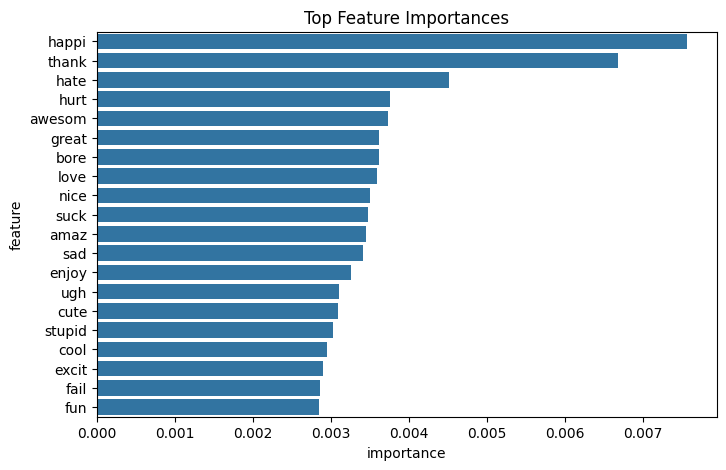

In [47]:
importance_features(xgb_model, vectorizer, 20)

**Observation**
- Regarding the importance of words, the TOP-20 included words that clearly identify the nature of the post, without unnecessary symbols or illogical words, which is quite good.

# Vectorization of texts using TF-IDF. Classifier training, analysis of accuracy and influence of words.

In [59]:
tfidf = TfidfVectorizer(    
    max_features = 5000,
    min_df = 3,
    max_df = 0.8,
    ngram_range = (1, 2))
raw_tfidf = tfidf.fit_transform(raw_df['clean_text'])

In [60]:
X_train_tfidf = tfidf.transform(raw_df.loc[train_idx, 'clean_text'])
X_test_tfidf = tfidf.transform(raw_df.loc[test_idx, 'clean_text'])

In [61]:
xgb_random_tdidf = xgb_random.fit(X_train_tfidf, y_train_enc)
xgb_model_tdidf = xgb_random_tdidf.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [62]:
print("Найкращі параметри:", xgb_random_tdidf.best_params_)
print("Найкращий CV F1:", round(xgb_random_tdidf.best_score_, 4))

Найкращі параметри: {'subsample': 1.0, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
Найкращий CV F1: 0.7065


F1 score on Training: 0.8474



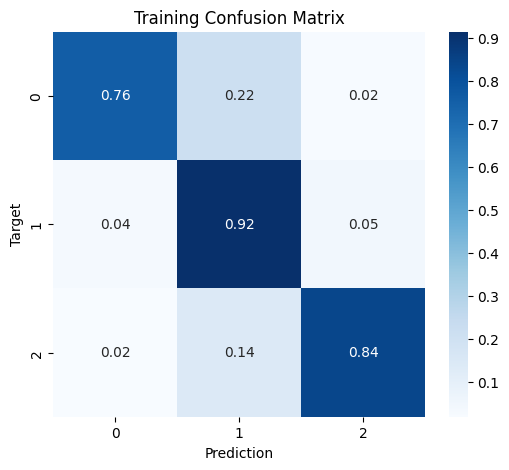


Classification Report for Training:

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      5447
           1       0.78      0.92      0.84      7782
           2       0.91      0.84      0.87      6007

    accuracy                           0.85     19236
   macro avg       0.87      0.84      0.85     19236
weighted avg       0.86      0.85      0.85     19236


AUROC for Training: 0.9609
F1 score on Validation: 0.7053



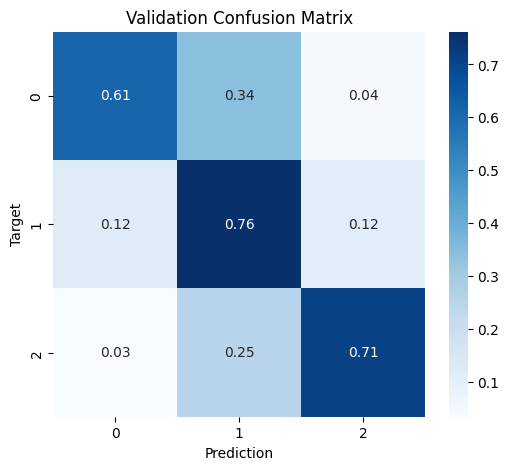


Classification Report for Validation:

              precision    recall  f1-score   support

           0       0.74      0.61      0.67      2334
           1       0.64      0.76      0.69      3335
           2       0.79      0.71      0.75      2575

    accuracy                           0.70      8244
   macro avg       0.72      0.70      0.71      8244
weighted avg       0.71      0.70      0.71      8244


AUROC for Validation: 0.8498


In [63]:
classify_analysis(y_train_enc, X_train_tfidf, xgb_model_tdidf, 'Training')
classify_analysis(y_test_enc, X_test_tfidf, xgb_model_tdidf, 'Validation')

,feature,importance
1791,happi,0.007785
4244,thank,0.006912
3609,sad,0.004698
1814,hate,0.004465
4110,suck,0.004417
2474,love,0.004412
2910,nice,0.004347
404,bore,0.004217
95,amaz,0.004100
4557,ugh,0.003899


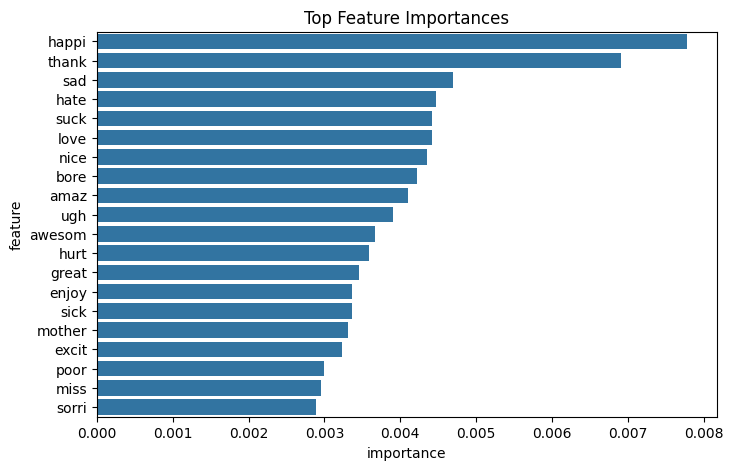

In [64]:
importance_features(xgb_model_tdidf, tfidf, 20)

**Observation**
- The results obtained based on TFIDF vectorization, although they showed higher quality metrics on the training sample, nevertheless indicate a clear overtraining, compared to the results on the validation. So in this case, taking into account the results and the modeling time (on TFIDF vectors it is trained much longer than on BoW) for further use in this experiment I would choose the model on Bag of words vectors. At the same time, in both cases it would be worth trying to analyze the errors in more detail and fine-tune the model.
- Regarding the importance of words, in both the case of Bag of Words and TFIDF we observe logical words by which it is possible to identify the nature of the post. At the same time, the first 4 positions in different orders are occupied by the same words (except for sad), which once again confirms their significance.

# Classification error analysis with TF-IDF vectorization

In [65]:
y_pred = xgb_model_tdidf.predict(X_test_tfidf)
y_pred_labels = label_encoder.inverse_transform(y_pred)

results = pd.DataFrame({
    "text": raw_df.loc[test_idx, "clean_text"].values,
    "true": y_test.values,
    "pred": y_pred_labels
})

errors = results[results["true"] != results["pred"]]

print(f"Загалом помилок: {len(errors)}")
print(f"Частка помилок: {len(errors) / len(results):.3f}")

display(errors.head(20))

Загалом помилок: 2432
Частка помилок: 0.295


,text,true,pred
2,wear pair trouser loos last year tight year,negative,neutral
11,oh ok thank dont know courthous id either lear...,negative,neutral
15,time get readi wrk ! ahh dnt wan na goo !,negative,neutral
16,wonder mother natur make life miser,negative,neutral
19,bout tuh head find sum wher tuh go chill,positive,neutral
22,? focus tom much see belov barack ! oh no ! mu...,neutral,negative
23,three hour hair still straight,negative,neutral
24,assum mean nd item nest line no invert call tr...,negative,neutral
25,flore aww ! guess doesnt blackberrymesseng,negative,neutral
26,husband loos gover job due downsiz look new jo...,negative,neutral


In [66]:
error_by_class = (
    results.assign(error = results["true"] != results["pred"])
    .groupby("true")["error"]
    .mean()
    .sort_values(ascending=False)
)

display(error_by_class)

print("Найбільш часті помилки у класах")

confusions = (
    errors.groupby(["true", "pred"])
    .size()
    .sort_values(ascending=False)
)

display(confusions)

true
negative    0.386461
positive    0.285825
neutral     0.238081
Name: error, dtype: float64

Найбільш часті помилки у класах


true      pred    
negative  neutral     799
positive  neutral     650
neutral   negative    410
          positive    384
negative  positive    103
positive  negative     86
dtype: int64

**Observation**
- The error rate of the validation dataset is about 30%. Most of them are related to incorrect identification of negative sentiment (the share of incorrectly classified posts is 38.6%), most of them identifying it as neutral. This problem is also present with the positive class (28.5%). This situation may indicate the limitations of the model in determining the weakly expressed emotional nature of the text.
- According to the examples of text misclassification, the model is wrong in cases of texts with an implicit emotional nature, ambiguous, short messages.
- Regarding the improvement of the results, it is worth paying attention to the processing of abbreviations, slang and spelling errors. Also try to use logistic regression, which also gave a good result based on Bag of Words vectors only using regularization to reduce overtraining. In addition, after improved preprocessing, it is worth choosing parameters for the TFIDF vectorization itself.